
revision version log:
v1- created 1/14/26
-importing processing code from revision cloud autoencoder iteration. importing modeling code from local_Fig_decode_setup_v18.ipynb


original changelog:
v9- 9/26/24'; added updated time-series importing logic to ensure congruence across different csripts.
10/10/24; added Late IA vs Early RS comparison for decoding (+ weight testing)
using new packaging logic develoepd ~ v7
v11- 10/29/24
-adding cross-stage out of distribution testing for decoding (e.g. train on IA Error vs RS Erorr, test on IA correct vs RS Correct)
v12- 11/11/24 running on 3,15,250, 0.01 abs spike detection params
v13- 11/14/24- running on gauss_smooth + 80% cutoff + temporal dedup, also deleting PCA save step as you are regenerating PC projection with new boostrap pulls in the plotting version of this
v15- 12/4/24- testing # of Early RS COrrect trials occuring b4 and after the Early RS Error trials.
v18- drop time-dependent activity decoding, introduced stratified kfold split


## Setup


In [1]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import shutil
import time
import json
from datetime import datetime
from functools import partial
from sklearn import svm, metrics, model_selection

from joblib import Parallel, delayed  # from functools import partial #for specific type of parallel deployment
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

#load preprocess specific functions
import notebook_setup
info = notebook_setup.setup()
from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 

preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
# from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from preprocessing_utils import dataset_obj_to_df, transform_all_datasets, extract_trial_windows, create_subject_trial_tseries_df
from preprocess_functions.shuffle_methods import prepare_shuffle_data, create_shuffled_df_preconverted, log_shuffle_run, get_latest_shuffle_folder, load_latest_shuffle_run
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import *
from phase_enrich_timeseries_decode import plot_unit_enrich_by_phase_summary

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sns_plotting_config import * #import dicts containing default plot params
try:
    pd.get_option('mode.use_inf_as_null')
except pd._config.config.OptionError:
    pd._config.config.register_option('mode.use_inf_as_null', False, "Deprecated - for seaborn 0.12.x compatibility")
    
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()

# Create output directory with run ID
results_dir = config['data']['results_dir']
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)

#set data location
data_dir = config['data']['data_dir']
source_dataset_location= config['data']['source_dataset_location']

#hardcoded/old links for checking
hardcode_results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
hardcode_data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
hardcode_source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

#print config paths for verification
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_dir}")
print(f"Source dataset location: {source_dataset_location}")
# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')

##IMPORT TIME_SERIES
#declare loc/names of files to read
output_folder = os.getcwd() +"/output/"
new_trial_df_filename = Path(r"python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet")
# new_trial_df_filename = Path(r"python-made_trial_timeseries_raster_2025-12-21 12.parquet")
# new_trial_df_filename = f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_df_filename = data_dir /  new_trial_df_filename
print(f"loading_dataset {new_trial_df_filename} \n from {trial_df_filename}")
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm.tail()
#col names for analysis
stage_col = 'task_phase_vec'
subject_col = 'subject_name'
# subject_col = 'name'
unit_ID_col = 'neuron_id'
# unit_ID_col = 'unique_ID'
# get stage names from data
stage_names = sorted(trial_tseries_df_norm[stage_col].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col) 
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = subject_col)#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')[unit_ID_col].nunique()
subject_stage_info_df.tail()


C:\Users\13car\AppData\Local\Temp\ipykernel_266032\4284187205.py:43: FutureWarning: 
: boolean
    use_inf_as_null had been deprecated and will be removed in a future
    version. Use `use_inf_as_na` instead.

  pd.get_option('mode.use_inf_as_null')


Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value

,subject_name,geno_day,task_phase_vec,neuron_id,num_enriched_units,num_units,trial_num,count_of_trials,over_5
198,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-100, 9_3_HET_RS3-109, 9_3_HET_RS3...",24,177,"[3, 5]",2,"[False, False]"
199,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-129, 9_3_HET_RS3-132, 9_3_HET_RS3...",10,177,"[17, 19, 21]",3,"[True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-128, 9_3_HET_RS3-130, 9_3_HET_RS3...",12,177,"[18, 20]",2,"[True, True]"
201,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-11, 9_3_HET_RS3-129, 9_3_HET_RS3-...",19,177,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
202,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-152, 9_3_HET_RS3-169, 9_3_HET_RS3...",5,177,"[34, 35, 36, 38]",4,"[True, True, True, True]"


<Figure size 640x480 with 0 Axes>

In [2]:
print(numeric_col)

Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s',
       '-1.5s to -1.25s', '-1.25s to -1.0s', '-1.0s to -0.75s',
       '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s',
       '0.0s to 0.25s', '0.25s to 0.5s', '0.5s to 0.75s', '0.75s to 1.0s',
       '1.0s to 1.25s', '1.25s to 1.5s', '1.5s to 1.75s', '1.75s to 2.0s',
       '2.0s to 2.25s', '2.25s to 2.5s', '2.5s to 2.75s', '2.75s to 3.0s',
       '3.0s to 3.25s', '3.25s to 3.5s', '3.5s to 3.75s', '3.75s to 4.0s',
       '4.0s to 4.25s', '4.25s to 4.5s', '4.5s to 4.75s', '4.75s to 5.0s',
       '5.0s to 5.25s', '5.25s to 5.5s', '5.5s to 5.75s', '5.75s to 6.0s',
       '6.0s to 6.25s', '6.25s to 6.5s', '6.5s to 6.75s', '6.75s to 7.0s',
       '7.0s to 7.25s', '7.25s to 7.5s', '7.5s to 7.75s', '7.75s to 8.0s',
       '8.0s to 8.25s', '8.25s to 8.5s', '8.5s to 8.75s', '8.75s to 9.0s',
       '9.0s to 9.25s', '9.25s to 9.5s', '9.5s to 9.75s', '9.75s to 1

## Import neural datasets + set parameters

In [3]:
# datasets_location = "/content/drive/MyDrive/Colab Notebooks/"# TACO_location = "Time-series activity datasets"
folder_loc = results_dir
os.chdir(folder_loc)
#make figure storage
cwd = os.getcwd()
print(f" CWD: {cwd}")

date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
output_folder =folder_loc / Path(f"figure_5_prep_mid_decoding figures_{date_tag}/")
make_folder(output_folder)
os.chdir(output_folder)
subfolder_names= make_figtype_subfolders(output_folder)
#save hyperparameters: 
# open a file for writing
with open('hyper_param_dict.json', 'w') as f:     # write the dictionary to the file in JSON format
    json.dump(hyper_param_dict, f)
## save metatdata of current run
f = open("latest_figure_5_decode_setup_run_source_data.txt", "w")
f.write(f"latest_figure_5_decode_setup_source Activity time-series record used : {str(new_trial_df_filename)}")
f.close()
os.getcwd()

 CWD: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\svg_plots' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\pdf_plots' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\png_plots' has been created.


'C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_24_Jan_2026'

#### Import Single Trial time-series dataset with enrichment information

#### Set parameter name/info for reference


In [4]:
#set unit name and type of data
data_type = 'post_outcome_activity'
units = 'cells'
# unit_ID_col=  "neuron_id"
#phase related information
single_trial_tseries_w_enrich = trial_tseries_df_norm
id_col = [col for col in single_trial_tseries_w_enrich.columns if 'id' in col.lower()][0]
print(id_col)
phase_names = single_trial_tseries_w_enrich.task_phase_vec.unique()
#determine comparisosn to be decoding on
class_comparisons = [
    [phase_names[0], phase_names[1]], #early IA corr vs. early IA err
    [phase_names[0], phase_names[3]],#- early IA corr vs. early RS corr
    [phase_names[1], phase_names[4]],#  - early IA err vs.l early RS err
    [phase_names[3], phase_names[4]],#- early RS corr vs. early RS err
    [phase_names[2], phase_names[5]],#- late IA vs. late RS
    [phase_names[0], phase_names[2]],#- early IA corr vs. late IA
    [phase_names[3], phase_names[5]],#- early RS corr vs. late RS
    [phase_names[2], phase_names[3]],#late IA vs early RS corr
                     ]
print(numeric_col)
print(phase_names)
class_comparisons

neuron_id
Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s',
       '-1.5s to -1.25s', '-1.25s to -1.0s', '-1.0s to -0.75s',
       '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s',
       '0.0s to 0.25s', '0.25s to 0.5s', '0.5s to 0.75s', '0.75s to 1.0s',
       '1.0s to 1.25s', '1.25s to 1.5s', '1.5s to 1.75s', '1.75s to 2.0s',
       '2.0s to 2.25s', '2.25s to 2.5s', '2.5s to 2.75s', '2.75s to 3.0s',
       '3.0s to 3.25s', '3.25s to 3.5s', '3.5s to 3.75s', '3.75s to 4.0s',
       '4.0s to 4.25s', '4.25s to 4.5s', '4.5s to 4.75s', '4.75s to 5.0s',
       '5.0s to 5.25s', '5.25s to 5.5s', '5.5s to 5.75s', '5.75s to 6.0s',
       '6.0s to 6.25s', '6.25s to 6.5s', '6.5s to 6.75s', '6.75s to 7.0s',
       '7.0s to 7.25s', '7.25s to 7.5s', '7.5s to 7.75s', '7.75s to 8.0s',
       '8.0s to 8.25s', '8.25s to 8.5s', '8.5s to 8.75s', '8.75s to 9.0s',
       '9.0s to 9.25s', '9.25s to 9.5s', '9.5s to 9.75s', '

[['Early_IA_Correct', 'Early_IA_Error'],
 ['Early_IA_Correct', 'Early_RS_Correct'],
 ['Early_IA_Error', 'Early_RS_Error'],
 ['Early_RS_Correct', 'Early_RS_Error'],
 ['Late_IA', 'Late_RS'],
 ['Early_IA_Correct', 'Late_IA'],
 ['Early_RS_Correct', 'Late_RS'],
 ['Late_IA', 'Early_RS_Correct']]

## Create summary viz of enriched units info and frame data


In [5]:
## summary plot function 
def plot_unit_enrich_by_phase_summary(fig_size, trial_type_by_subj,phase_enrichment_by_subj,geno_order, phase_names, numeric_col, name_col = 'name'):
    unit_count_fig, axs = plt.subplots(2,2, figsize = fig_size, layout = 'constrained')
    axs = axs.flat
    # plot # recorded trials by phase
    sns.heatmap(ax = axs[0], data= trial_type_by_subj.set_index(name_col).drop('geno_day', axis = 1).T, annot = True)
    axs[0].set_title('# of recorded trials in each phase, by dataset');
    #plot timebin recorded of a phase, by dataset
    sns.heatmap(ax = axs[1], data= trial_type_by_subj.set_index(name_col).drop('geno_day', axis = 1).T*len(numeric_col),linewidth = 0.1, annot = True, fmt = '.0f')
    axs[1].set_title('# of recorded timebins in phase, by dataset');
    # plot # cells enriched in phase, by phase
    sns.heatmap(ax = axs[2], data=phase_enrichment_by_subj.set_index(name_col).drop('geno_day', axis = 1).T, linewidth = 0.1, annot = True, fmt = '.0f')
    axs[2].set_title('# of cells enriched in phase, by dataset');
    #total enrichment by geno_day
    sns.heatmap(ax = axs[3], data=phase_enrichment_by_subj.groupby('geno_day').sum().loc[geno_order,phase_names].T,linewidth = 0.1, annot = True, fmt = '.0f')
    axs[3].set_title('Total # units in pseudopop enriched in phase, by geno_day');
    #figre metadata
    unit_count_fig.subplots_adjust(top = 0.9);
    unit_count_fig.suptitle(f"Summary of Total # of trials and # of usable timebins for each dataset, by task phase");
    return unit_count_fig, axs


C:\Users\13car\AppData\Local\Temp\ipykernel_266032\2245857508.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.heatmap(ax = axs[3], data=phase_enrichment_by_subj.groupby('geno_day').sum().loc[geno_order,phase_names].T,linewidth = 0.1, annot = True, fmt = '.0f')
C:\Users\13car\AppData\Local\Temp\ipykernel_266032\2245857508.py:18: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  unit_count_fig.subplots_adjust(top = 0.9);


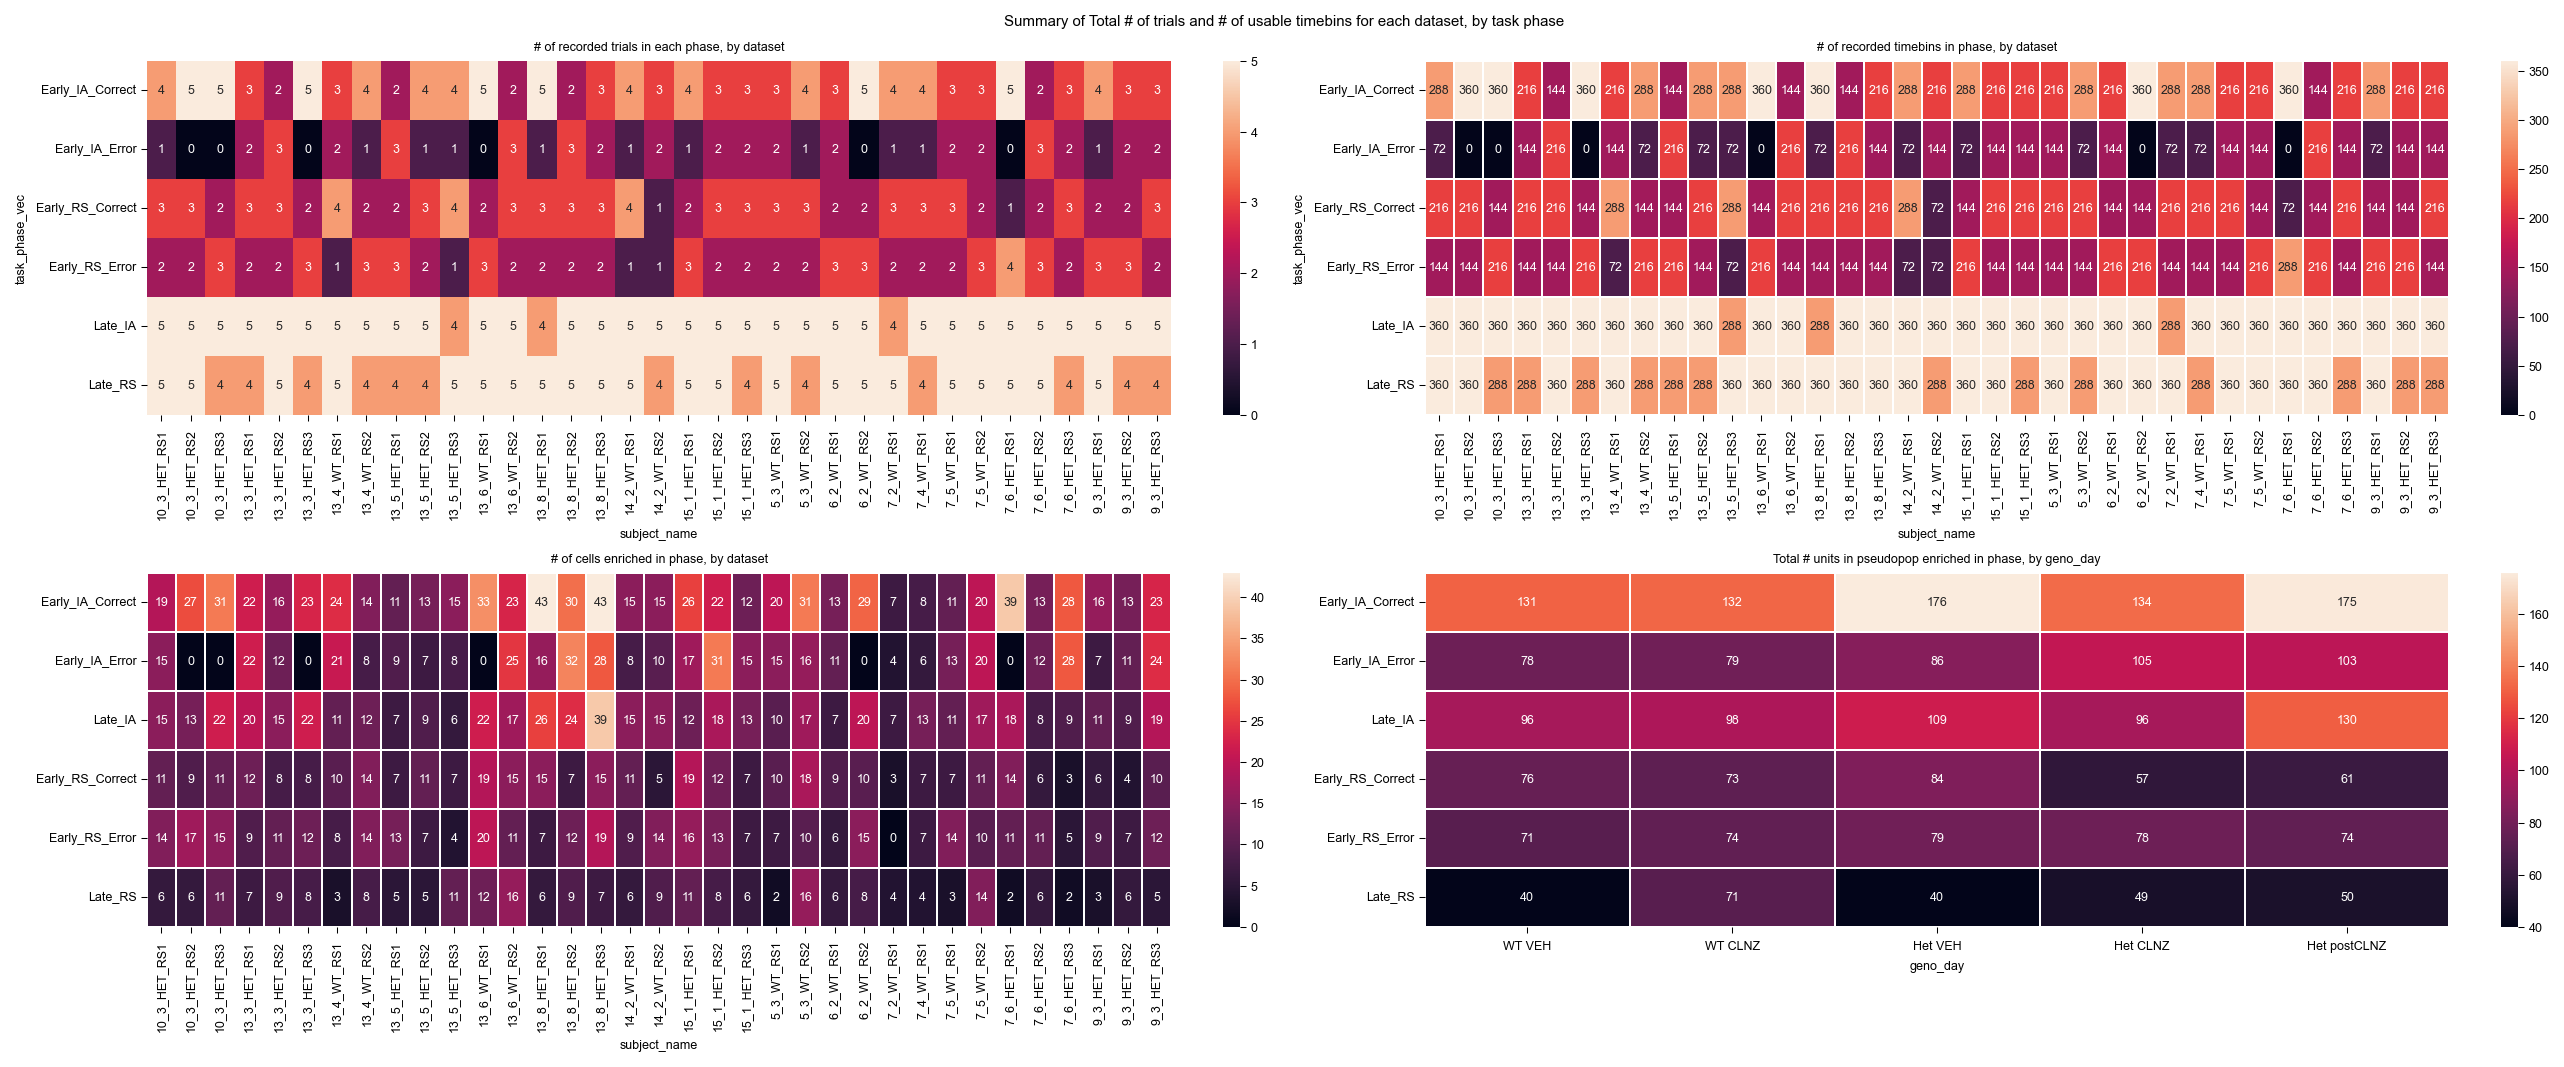

In [6]:

#gather trial types
trial_type_by_subj = get_num_trials_by_type_in_subject(single_trial_tseries_w_enrich, task_phase_col= 'task_phase_vec', name_col = subject_col).fillna(0);
trial_type_by_subj[phase_names] = trial_type_by_subj[phase_names].astype(int)
neuron_enrichment =  single_trial_tseries_w_enrich.groupby([subject_col, 'geno_day', id_col])[phase_names].mean().reset_index()
phase_enrichment_by_subj = neuron_enrichment[list(phase_names) + [subject_col, 'geno_day']].groupby(by = [subject_col, 'geno_day']).sum().reset_index()

#make figures
unit_count_fig, axs = plot_unit_enrich_by_phase_summary((17,7), trial_type_by_subj,phase_enrichment_by_subj,geno_order_w_WT_CLNZ, phase_names,numeric_col, name_col = subject_col)
#save as a fig
pdf_name = output_folder / Path(f"Enrichment of {units} and # of samples per phase")
save_fig_as_filetype_list(unit_count_fig, pdf_name , subfolder_names, ['pdf', 'png'])

### New Pseudopop generation by resampling cell activity time-series

In [7]:
#imported from autoencoder:
# ## helper functions imported from phase_enrich_timeseries_decode.py module
def get_dataset_names_in_geno(dataset_name_by_geno_day,
                              geno_day,
                              subject_name_col = 'subject_name'):
    datasets_in_geno = dataset_name_by_geno_day.loc[dataset_name_by_geno_day.geno_day == geno_day,subject_name_col].values[0] #get name of datasets in current geno_day setup
    return datasets_in_geno

 ## imported subfunc for cuDF speedup
def get_tseries_of_dataset(timeseries_df, 
                           dataset_name, 
                           subject_name_col = 'subject_name'):
    #get time-series that are occurign in phase of interest
    dataset_df_slice = timeseries_df.loc[timeseries_df[subject_name_col] == dataset_name]
    return dataset_df_slice

def get_tseries_in_phase(timeseries_df, phase_name):
    phase_dataset_df_slice = timeseries_df.loc[timeseries_df.task_phase_vec == phase_name]
    return phase_dataset_df_slice

def get_tseries_phase_enrich_cells(tseries_df, unit_ID_col, enrichment_ID_df, dataset_name, e_phase_name,subject_name_col = 'subject_name'):
    enrich_in_phase_unit_IDs = get_dataset_units_enrich_in_phase(enrichment_ID_df, unit_ID_col, dataset_name, e_phase_name, subject_name_col = subject_name_col) #get unit IDs that are enriched in phase of interest
    enrich_in_phase_dataset_df = tseries_df.loc[tseries_df[unit_ID_col].isin(enrich_in_phase_unit_IDs)]#get unit time-series only if they enriched in phase of interest
    return enrich_in_phase_dataset_df, enrich_in_phase_unit_IDs

def get_dataset_units_enrich_in_phase(enrich_unit_by_name_phase_df,
                                       unit_ID_col,
                                         dataset_name,
                                           stage_of_interest,
                                           subject_name_col = 'subject_name'):
    name_mask = enrich_unit_by_name_phase_df[subject_name_col] == dataset_name
    phase_mask = enrich_unit_by_name_phase_df.task_phase_vec == stage_of_interest
    enrich_in_phase_unit_IDs =enrich_unit_by_name_phase_df.loc[phase_mask&name_mask, unit_ID_col].values[0]
    return enrich_in_phase_unit_IDs

def horzcat_all_trials(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=False):
    if drop_pre_outcome:
        print("drop pre outcome called")
        tseries_cols = [col for col in tseries_cols if "-" not in col]
    grouped = {
        trial: group.set_index(unit_col_name)[tseries_cols]
        for trial, group in timeseries_df.groupby('trial_num', sort=False)
    }
    return pd.concat(grouped.values(), axis=1)

def horzcat_all_trials_original(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=False):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col] 
    trial_slice_storage = []
    for trial in timeseries_df.trial_num.unique():
        trial_slice = timeseries_df.loc[timeseries_df.trial_num == trial].set_index(unit_col_name)
        trial_slice_storage.append(trial_slice.loc[:,tseries_cols])
    return pd.concat(trial_slice_storage, axis=1)

# Test
result_orig = horzcat_all_trials_original(trial_tseries_df_norm, numeric_col,unit_ID_col)
result_opt = horzcat_all_trials(trial_tseries_df_norm, numeric_col,unit_ID_col)

print("Identical:", result_orig.equals(result_opt))
print("Shape match:", result_orig.shape == result_opt.shape)
print("Columns match:", list(result_orig.columns) == list(result_opt.columns))
print("Index match:", list(result_orig.index) == list(result_opt.index))

def make_dataset_matrix_store_only(phase_names, 
                                   trial_tseries_df_norm,
                                   unit_ID_col,
                                   enrich_unit_ID_by_name_df,
                                    numeric_col,
                                    trial_list_by_dataset,
                                   dataset_name_by_geno_day,
                                   phase_enrichment_by_subj,
                                     subject_name_col = 'subject_name'):
    """TO- create a dict where key1 = stage the pseudopop is enriched in, key 2 = stage to look for activity of, and key 3- genotype of current datset"""
    ppop_data,stage_geno_tseries = dict(), dict()
    iter_ct = 0
    for e_phase in phase_names:
        ppop_data[e_phase],stage_geno_tseries[e_phase] = {},{}
        print("Get enrich in ",e_phase, "act. in ", phase_names)

        for act_phase in phase_names:
            datasets_w_phase_act = trial_list_by_dataset.loc[trial_list_by_dataset.task_phase_vec == act_phase][subject_name_col].unique()
            ppop_data[e_phase][act_phase],stage_geno_tseries[e_phase][act_phase]= {},{}

            for geno_day in dataset_name_by_geno_day.geno_day.unique():
                datasets_in_geno = get_dataset_names_in_geno(dataset_name_by_geno_day,geno_day, subject_name_col = subject_name_col)
                geno_dataset_w_act = [name for name in datasets_in_geno if name in datasets_w_phase_act]
                current_ppop_draw = dict()
                
                for dataset in geno_dataset_w_act:
                    iter_ct = iter_ct+1
                    #check if > 0 cells are enriched in stage
                    if phase_enrichment_by_subj.set_index(subject_name_col).loc[dataset, e_phase] > 0:
                        phase_dataset_df = get_tseries_in_phase(get_tseries_of_dataset(trial_tseries_df_norm,dataset, subject_name_col = subject_name_col), act_phase)
                        e_in_phase_data_df,e_in_stage_ID =get_tseries_phase_enrich_cells(phase_dataset_df, unit_ID_col,
                                                                                         enrich_unit_ID_by_name_df, dataset, e_phase, subject_name_col = subject_name_col)
                        current_ppop_draw[dataset] =  horzcat_all_trials_original(e_in_phase_data_df,numeric_col, unit_ID_col)
                ppop_data[e_phase][act_phase][geno_day] =current_ppop_draw
    return ppop_data

Identical: True
Shape match: True
Columns match: True
Index match: True


#### Get all time-series corresponding to dataset N

In [8]:
single_trial_tseries_w_enrich= single_trial_tseries_w_enrich.assign(**{'any_enrichment':  single_trial_tseries_w_enrich[phase_names].sum(axis = 1)})

trial_list_by_dataset = get_trial_num_in_phase_by_dataset( single_trial_tseries_w_enrich, name_col = subject_col)
##important- threshold to take datasets with >1 trials per section ( to have enough space of neurons)
trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]
enrich_unit_ID_by_name_df =get_ID_enriched_units_by_phase(single_trial_tseries_w_enrich, ID_col= unit_ID_col, bool_col_tseries_enriched = 'enriched_in_phase', subj_name_col = subject_col )
dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')[subject_col].unique().reset_index()
#add unique identifier that's (dataset_name + neuron_ID) to retain neuron ID info

In [9]:
single_trial_tseries_w_enrich.head()

,trial_num,cell,subject_name,session,geno,task_phase_vec,normalized,datatype,neuron_id,day,...,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome,any_enrichment,enriched_in_phase,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial
0,1,cell_1,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-1,1,...,0.0,0.0,0.0,1.0,1.0,False,1.0,nonneg_frames,0.0,False
1,1,cell_10,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-10,1,...,0.0,0.0,0.0,1.0,1.0,False,1.0,nonneg_frames,0.0,False
3,1,cell_101,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-101,1,...,0.0,0.0,0.0,0.0,0.0,False,1.0,nonneg_frames,0.0,False
5,1,cell_104,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-104,1,...,1.0,1.0,0.0,1.0,4.0,True,1.0,nonneg_frames,0.0,False
8,1,cell_107,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-107,1,...,0.0,0.0,1.0,1.0,1.0,False,1.0,nonneg_frames,0.0,False


In [10]:
enrich_unit_ID_by_name_df.tail()

,subject_name,geno_day,task_phase_vec,neuron_id,num_enriched_units
198,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-100, 9_3_HET_RS3-109, 9_3_HET_RS3...",24
199,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-129, 9_3_HET_RS3-132, 9_3_HET_RS3...",10
200,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-128, 9_3_HET_RS3-130, 9_3_HET_RS3...",12
201,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-11, 9_3_HET_RS3-129, 9_3_HET_RS3-...",19
202,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-152, 9_3_HET_RS3-169, 9_3_HET_RS3...",5


## Find accuracy of decoding in distribution / record results 

#### package all real enrichewd cell activations for future use

In [11]:
id_col = [col for col in single_trial_tseries_w_enrich.columns if 'id' in col.lower()][0]
print(id_col)

neuron_id


In [12]:
## make real dataset storage
dataset_name_by_geno_day
phase_enrichment_by_subj
class_matrix_store  = make_dataset_matrix_store_only(phase_names, 
                                                     single_trial_tseries_w_enrich,
                                                     unit_ID_col,
                                                     enrich_unit_ID_by_name_df,
                                                       numeric_col,
                                                         trial_list_by_dataset,
                                                         dataset_name_by_geno_day,
                                                         phase_enrichment_by_subj,
                                                         subject_name_col = subject_col )

Get enrich in  Early_IA_Correct act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_IA_Error act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Late_IA act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_RS_Correct act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_RS_Error act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Late_RS act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']


In [13]:
numeric_col

Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s',
       '-1.5s to -1.25s', '-1.25s to -1.0s', '-1.0s to -0.75s',
       '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s',
       '0.0s to 0.25s', '0.25s to 0.5s', '0.5s to 0.75s', '0.75s to 1.0s',
       '1.0s to 1.25s', '1.25s to 1.5s', '1.5s to 1.75s', '1.75s to 2.0s',
       '2.0s to 2.25s', '2.25s to 2.5s', '2.5s to 2.75s', '2.75s to 3.0s',
       '3.0s to 3.25s', '3.25s to 3.5s', '3.5s to 3.75s', '3.75s to 4.0s',
       '4.0s to 4.25s', '4.25s to 4.5s', '4.5s to 4.75s', '4.75s to 5.0s',
       '5.0s to 5.25s', '5.25s to 5.5s', '5.5s to 5.75s', '5.75s to 6.0s',
       '6.0s to 6.25s', '6.25s to 6.5s', '6.5s to 6.75s', '6.75s to 7.0s',
       '7.0s to 7.25s', '7.25s to 7.5s', '7.5s to 7.75s', '7.75s to 8.0s',
       '8.0s to 8.25s', '8.25s to 8.5s', '8.5s to 8.75s', '8.75s to 9.0s',
       '9.0s to 9.25s', '9.25s to 9.5s', '9.5s to 9.75s', '9.75s to 1

#### New- save out of distrib activation matrices and cell IDs

In [14]:
# Script to record cells and mean activity per class for out-of-distribution decoding
from matrix_resample_utils import * 
#create out of distribution handles
out_of_dist_train_sets = [
    [phase_names[0], phase_names[3]],#train on- early IA corr vs. early RS corr
     [phase_names[1], phase_names[4]],#train on- early IA err vs.l early RS err
    [phase_names[0], phase_names[1]],#train on-early IA corr vs. early IA err
    [phase_names[3], phase_names[4]],#train on- early RS corr vs. early RS err
    ]
out_of_dist_test_sets = [
    [phase_names[1], phase_names[4]],#test on- early IA err vs.l early RS err
    [phase_names[0], phase_names[3]],#test on- early IA corr vs. early RS corr
    [phase_names[3], phase_names[4]],##test on- early RS corr vs. early RS err
    [phase_names[0], phase_names[1]],##test on- early IA corr vs. early IA err
    ]
print(f"train sets: {out_of_dist_train_sets}")
print(f"Test sets: {out_of_dist_test_sets}")
print(f"train sets: {out_of_dist_train_sets}")
print(f"Test sets: {out_of_dist_test_sets}")

cell_activity_records = []
num_resample = 400
n_pseudopop_runs = 1000 #number of times you 1) create pseudopop and 2) decode with it
reg_penalty = 'l2'
k_folds = 4 #first iter is 5 fold cv
test_size = 0.25 #new test size
## set
phase_keys = class_matrix_store.keys()

for n_run in range(n_pseudopop_runs):
    for e_phase in phase_keys:
        for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys():
            # Resample into class matrices
            ensemble_resample_in_phase_dict = {}
            for class_name in phase_keys:
                class_matrix = resample_into_class_matrix(class_matrix_store, num_resample, e_phase, class_name, geno_day_curr)
                ensemble_resample_in_phase_dict[class_name] = class_matrix

            for phase_count, phase_pair in enumerate(out_of_dist_train_sets):
                class_0_train, class_1_train = phase_pair[0], phase_pair[1]
                test_pair = out_of_dist_test_sets[phase_count]
                class_0_test, class_1_test = test_pair[0], test_pair[1]

                # Build train matrix
                class_mat_0_train = ensemble_resample_in_phase_dict[class_0_train]
                class_mat_1_train = ensemble_resample_in_phase_dict[class_1_train]
                concat_matrix_train, concat_labels_train = fast_pack_data_local(class_mat_0_train, class_mat_1_train, 0, 1)

                # Build test matrix
                class_mat_0_test = ensemble_resample_in_phase_dict[class_0_test]
                class_mat_1_test = ensemble_resample_in_phase_dict[class_1_test]
                concat_matrix_test, concat_labels_test = fast_pack_data_local(class_mat_0_test, class_mat_1_test, 0, 1)

                # Get cell IDs
                unit_IDs_test = concat_matrix_test.index.values
                unit_IDs_train = concat_matrix_train.index.values

                # Filter to cells present in both
                train_IDs_in_test_bool = [u in unit_IDs_test for u in unit_IDs_train]
                test_IDs_in_train_bool = [u in unit_IDs_train for u in unit_IDs_test]

                # Common cells
                common_cell_ids = unit_IDs_train[train_IDs_in_test_bool]

                # Pivot and filter matrices
                concat_matrix_test_arr = concat_matrix_test.T.values[:, test_IDs_in_train_bool]
                concat_matrix_train_arr = concat_matrix_train.T.values[:, train_IDs_in_test_bool]

                # Mean activity per class per cell
                mean_activity = {
                    'c0_train_mean': concat_matrix_train_arr[concat_labels_train == 0].mean(axis=0).astype(np.float32),
                    'c1_train_mean': concat_matrix_train_arr[concat_labels_train == 1].mean(axis=0).astype(np.float32),
                    'c0_test_mean': concat_matrix_test_arr[concat_labels_test == 0].mean(axis=0).astype(np.float32),
                    'c1_test_mean': concat_matrix_test_arr[concat_labels_test == 1].mean(axis=0).astype(np.float32),
                }

                record_key = f"{n_run}_{e_phase}_{geno_day_curr}_{class_0_train}_{class_1_train}_to_{class_0_test}_{class_1_test}"
                
                cell_activity_records.append({
                    'record_key': record_key,
                    'pseudopop_run': n_run,
                    'ensemble': e_phase,
                    'geno_day': geno_day_curr,
                    'train_on': f"{class_0_train}_{class_1_train}",
                    'test_on': f"{class_0_test}_{class_1_test}",
                    'cell_ids': common_cell_ids,
                    'n_cells': len(common_cell_ids),
                    **mean_activity
                })

cell_activity_df = pd.DataFrame.from_records(cell_activity_records)
print(f"Recorded {len(cell_activity_df)} combinations")
cell_activity_df.head()

train sets: [['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error'], ['Early_RS_Correct', 'Early_RS_Error']]
Test sets: [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_RS_Correct', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error']]
train sets: [['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error'], ['Early_RS_Correct', 'Early_RS_Error']]
Test sets: [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_RS_Correct', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error']]
Recorded 120000 combinations


,record_key,pseudopop_run,ensemble,geno_day,train_on,test_on,cell_ids,n_cells,c0_train_mean,c1_train_mean,c0_test_mean,c1_test_mean
0,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,"[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",94,"[0.276, 0.095, 0.1165, 0.1525, 0.325, 0.089, 0...","[0.0885, 0.0, 0.0, 0.016, 0.33425, 0.1345, 0.0...","[0.0, 0.145, 0.054, 0.035, 0.0, 0.0, 0.1085, 0...","[0.127, 0.0235, 0.0, 0.0, 0.141, 0.0, 0.055, 0..."
1,0_Early_IA_Correct_Het CLNZ_Early_IA_Error_Ear...,0,Early_IA_Correct,Het CLNZ,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,"[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",94,"[0.0, 0.145, 0.054, 0.035, 0.0, 0.0, 0.1085, 0...","[0.127, 0.0235, 0.0, 0.0, 0.141, 0.0, 0.055, 0...","[0.276, 0.095, 0.1165, 0.1525, 0.325, 0.089, 0...","[0.0885, 0.0, 0.0, 0.016, 0.33425, 0.1345, 0.0..."
2,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,"[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",94,"[0.276, 0.095, 0.1165, 0.1525, 0.325, 0.089, 0...","[0.0, 0.145, 0.054, 0.035, 0.0, 0.0, 0.1085, 0...","[0.0885, 0.0, 0.0, 0.016, 0.33425, 0.1345, 0.0...","[0.127, 0.0235, 0.0, 0.0, 0.141, 0.0, 0.055, 0..."
3,0_Early_IA_Correct_Het CLNZ_Early_RS_Correct_E...,0,Early_IA_Correct,Het CLNZ,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,"[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",94,"[0.0885, 0.0, 0.0, 0.016, 0.33425, 0.1345, 0.0...","[0.127, 0.0235, 0.0, 0.0, 0.141, 0.0, 0.055, 0...","[0.276, 0.095, 0.1165, 0.1525, 0.325, 0.089, 0...","[0.0, 0.145, 0.054, 0.035, 0.0, 0.0, 0.1085, 0..."
4,0_Early_IA_Correct_Het VEH_Early_IA_Correct_Ea...,0,Early_IA_Correct,Het VEH,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,"[13_3_HET_RS1-110, 13_3_HET_RS1-111, 13_3_HET_...",33,"[0.0, 0.083, 0.0035, 0.0065, 0.0025, 0.1045, 0...","[0.0, 0.0035, 0.0, 0.0, 0.0, 0.261, 0.015, 0.0...","[0.025, 0.00675, 0.0, 0.0, 0.0, 0.136, 0.266, ...","[0.0895, 0.0, 0.0, 0.0, 0.019166667, 0.0625, 0..."


In [15]:
cell_activity_file_name = output_folder / Path(f"Cell Activity (Out of Distrib) {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
cell_activity_df.to_parquet(cell_activity_file_name, compression='snappy')
print(f"cell activity file name: {cell_activity_file_name}")

cell activity file name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\Cell Activity (Out of Distrib) 1000 pseudopop post_outcome_activity 24_Jan_2026.parquet


#### Run real decoder

In [16]:
def get_test_precision_recall_acc(test_set_data, test_set_labels, trained_model):
#TO- given model already trained on test set, create prediction vec, then calculate precision and recall
    prediction_vec =trained_model.predict(test_set_data)
    true_positive_vec = test_set_labels*prediction_vec
    ## get score metrics
    precision = (1+np.sum(true_positive_vec))/(1+ np.sum(prediction_vec)) #precision = % of predicted 1 / true 1
    recall = (1+ np.sum(true_positive_vec))/ (1+np.sum(test_set_labels)) #recall =  % of predicted 1/ all 1
    acc = np.mean(prediction_vec == test_set_labels)
    return precision, recall,acc


## new- get cosine sim of class matrices:
def mean_class_cosine_sim(matrix, labels):
    """Cosine similarity between mean vectors of class 0 and class 1."""
    mean_0 = matrix[labels == 0].mean(axis=0)
    mean_1 = matrix[labels == 1].mean(axis=0)
    return np.dot(mean_0, mean_1) / (np.linalg.norm(mean_0) * np.linalg.norm(mean_1))

In [17]:
from matrix_resample_utils import * 

def run_N_stage_pair_decoders(class_matrix_store,class_comparisons, num_resample, test_size = 0.5, k_folds = 2, n_pseudopop_run_range = [0]):
    """To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  """
    all_run_record_store = []#create storage for all run information for later concat
    weight_records = []  # Storage for SVM weights and cell IDs
    #declare variables for local use
    reg_penalty = 'l2'
    
    phase_names = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix
                
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0 =ensemble_resample_in_phase_dict[class_0]
                    class_mat_1 =ensemble_resample_in_phase_dict[class_1]
                    concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels
                    cell_ids = concat_matrix.index.values  # Capture cell IDs BEFORE .T.values
                    concat_matrix = concat_matrix.T.values #.T.values of concat matrix is to reshape mat into what scikit wants from you
                    
                    cv = model_selection.StratifiedShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices
                    target_info = {"pseudopop_run_num": n_run, 'class_0': class_0,'class_1' : class_1,"enriched_group": e_phase, 'geno_day': geno_day_curr} #speficy info about what classes being decoded
                    # split_accuracy = [] #NOW, ONLY TAKE ACCURACY OF EACH SPLIT AND AVERAGE IT OVER SPLITS 
                    full_cosine_sim = mean_class_cosine_sim(concat_matrix, concat_labels)

                    for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels)), concat_labels)):
                        model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                        trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                        #get accuracy
                        prediction_vec =trained_model.predict(concat_matrix[test,:])
                        true_pos= np.sum([np.array([prediction_vec == 1]) &  np.array([concat_labels[test]==1])])
                        true_neg= np.sum([np.array([prediction_vec == 0]) &  np.array([concat_labels[test]==0])])
                        false_pos =  np.sum([np.array([prediction_vec == 1]) &  np.array([concat_labels[test]==0])])
                        false_neg =  np.sum([np.array([prediction_vec == 0]) &  np.array([concat_labels[test]==1])])
                        score_real = np.mean(prediction_vec == concat_labels[test])
                        
                        # Calculate cosine similarity between mean class vectors (using training & test data)
                        train_cosine_sim = mean_class_cosine_sim(concat_matrix[train], concat_labels[train])
                        test_cosine_sim = mean_class_cosine_sim(concat_matrix[test], concat_labels[test])

                        # Create unique decoder key for linking weights
                        decoder_key = f"{n_run}_{e_phase}_{geno_day_curr}_{class_0}_{class_1}_{split_count}"
                        
                        # Store weights and cell IDs
                        weight_records.append({
                            'decoder_key': decoder_key,
                            'weights': trained_model.coef_.flatten().astype(np.float32),
                            'cell_ids': cell_ids,
                            'intercept': trained_model.intercept_[0],
                            'train_class_0_mean': np.mean(concat_matrix[train][concat_labels[train] == 0], axis=0).astype(np.float32),
                            'train_class_1_mean': np.mean(concat_matrix[train][concat_labels[train] == 1], axis=0).astype(np.float32),
                            'test_class_0_mean': np.mean(concat_matrix[test][concat_labels[test] == 0], axis=0).astype(np.float32),
                            'test_class_1_mean': np.mean(concat_matrix[test][concat_labels[test] == 1], axis=0).astype(np.float32),
                        })

                        # precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                        curr_split_params = {**target_info,'split': split_count, 'accuracy': score_real,
                                             'decoder_key': decoder_key,  # Add key for linking to weights
                                             'num_features_used': trained_model.n_features_in_, 'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), 
                                             'train_pos_sample':  np.sum(concat_labels[train] ==1), 'train_neg_sample':np.sum(concat_labels[train] ==0),
                                             'test_pos_sample':np.sum(concat_labels[test]==1), 'test_neg_sample': np.sum(concat_labels[test]==0),
                                            'true_pos': true_pos,'true_neg':true_neg,'false_pos':false_pos, 'false_neg' :false_neg,
                                            'train_cosine_sim': train_cosine_sim, 'test_cosine_sim': test_cosine_sim, 'full_cosine_sim': full_cosine_sim
                                            }
                        all_run_record_store.append(curr_split_params)# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                    #after finishing split run, average then store
                    #how to average? 
                    # average_acc = np.mean(split_accuracy)
                    # split_summary = {**target_info,'mean_acc': average_acc} 
                    # all_run_record_store.append(split_summary) #append dict
                    # all_run_record_store.append(pd.DataFrame.from_records(split_summary)) #store performance information by split run
    #once done with all bootstraps, create from records
    all_run_record_store =pd.DataFrame.from_records(all_run_record_store)
    weight_save_df = pd.DataFrame.from_records(weight_records)
    return all_run_record_store, weight_save_df

In [18]:
# 5.18.24 stats: #1 run- Wall time: 28.7 s|# 10 runs- 5 minutes|# 20 runs-10min|# 500 runs- 4.5 hours
#5.19.24 stats (single storage, then as needed resample): #5 runs- 1.5 min|#10 iter = 3min 11|#20- 6 min
#hyperparameters for decoding
num_resample = 400
n_pseudopop_runs = 1000 #number of times you 1) create pseudopop and 2) decode with it
reg_penalty = 'l2'
k_folds = 4 #first iter is 5 fold cv
test_size = 0.25 #new test size
## set
n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0, n_pseudopop_runs, n_jobs)
print(start_end_iter)
# set up parallel batch, test once 
partial_param_svm_func = partial(run_N_stage_pair_decoders, class_matrix_store,class_comparisons, num_resample, test_size, k_folds )
test_decode = partial_param_svm_func([0])
test_decode

N_batches: 10
Batch_size: 100
[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]), array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164,
       165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177,
       178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190,
       191, 192, 193,

(     pseudopop_run_num           class_0           class_1    enriched_group  \
 0                    0  Early_IA_Correct    Early_IA_Error  Early_IA_Correct   
 1                    0  Early_IA_Correct    Early_IA_Error  Early_IA_Correct   
 2                    0  Early_IA_Correct    Early_IA_Error  Early_IA_Correct   
 3                    0  Early_IA_Correct    Early_IA_Error  Early_IA_Correct   
 4                    0  Early_IA_Correct  Early_RS_Correct  Early_IA_Correct   
 ..                 ...               ...               ...               ...   
 955                  0  Early_RS_Correct           Late_RS           Late_RS   
 956                  0           Late_IA  Early_RS_Correct           Late_RS   
 957                  0           Late_IA  Early_RS_Correct           Late_RS   
 958                  0           Late_IA  Early_RS_Correct           Late_RS   
 959                  0           Late_IA  Early_RS_Correct           Late_RS   
 
      geno_day  split  acc

In [19]:
len(test_decode)

2

In [20]:
# output_SVM_runs, weight_records = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
# Collect all parallel results first
parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
# Separate decode scores and weights
output_SVM_runs = [r[0] for r in parallel_results]
weight_records = [r[1] for r in parallel_results]  # Flatten the nested lists

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  7.4min remaining: 17.3min
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed:  7.5min remaining:  7.5min
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed:  7.5min remaining:  3.2min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:  7.6min finished


In [21]:
weight_records

[                                             decoder_key  \
 0      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 1      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 2      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 3      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 4      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 ...                                                  ...   
 95995       99_Late_RS_WT VEH_Early_RS_Correct_Late_RS_3   
 95996       99_Late_RS_WT VEH_Late_IA_Early_RS_Correct_0   
 95997       99_Late_RS_WT VEH_Late_IA_Early_RS_Correct_1   
 95998       99_Late_RS_WT VEH_Late_IA_Early_RS_Correct_2   
 95999       99_Late_RS_WT VEH_Late_IA_Early_RS_Correct_3   
 
                                                  weights  \
 0      [-1.0240909, 0.13702103, -0.27655149, -0.24926...   
 1      [-0.80594563, -0.026002869, -0.15736365, -0.15...   
 2      [-1.1908058, 0.13224043, -0.21418399, -0.05802...   
 3      [-1.1362371, 0

#### Save binary decoder + weights

In [22]:
print(len(output_SVM_runs))
# all_run_record_store = [pd.concat(x) for x in output_SVM_runs] #each elem of output = 1 paralell run 
decode_scores = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
decode_scores['classes decoded'] = decode_scores.class_0.str.cat(decode_scores.class_1, sep = '_v_').astype('category')
decode_scores = decode_scores.rename({'class_0': 'Phase1', 'class_1':'Phase2'}, axis = 1)
decode_scores[['enriched_group', 'Phase2', 'Phase1', 'geno_day']] = decode_scores[['enriched_group', 'Phase2', 'Phase1', 'geno_day']].astype('category')
print(decode_scores.info())
decode_scores

10
<class 'pandas.core.frame.DataFrame'>
Int64Index: 960000 entries, 0 to 95999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   pseudopop_run_num    960000 non-null  int32         
 1   Phase1               960000 non-null  category      
 2   Phase2               960000 non-null  category      
 3   enriched_group       960000 non-null  category      
 4   geno_day             960000 non-null  category      
 5   split                960000 non-null  int64         
 6   accuracy             960000 non-null  float64       
 7   decoder_key          960000 non-null  object        
 8   num_features_used    960000 non-null  int64         
 9   num_nonzero_coef     960000 non-null  int32         
 10  train_pos_sample     960000 non-null  int32         
 11  train_neg_sample     960000 non-null  int32         
 12  test_pos_sample      960000 non-null  int32         
 13  test_neg_sam

,pseudopop_run_num,Phase1,Phase2,enriched_group,geno_day,split,accuracy,decoder_key,num_features_used,num_nonzero_coef,...,true_neg,false_pos,false_neg,train_cosine_sim,test_cosine_sim,full_cosine_sim,timebin_size,run_end_time,dataset_folder_name,classes decoded
0,0,Early_IA_Correct,Early_IA_Error,Early_IA_Correct,Het CLNZ,0,0.995,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,94,91,...,99,1,0,0.555606,0.526694,0.553869,0.25,2026-01-24 11:49:36.466208,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
1,0,Early_IA_Correct,Early_IA_Error,Early_IA_Correct,Het CLNZ,1,0.990,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,94,91,...,98,2,0,0.547577,0.537962,0.553869,0.25,2026-01-24 11:49:36.466208,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
2,0,Early_IA_Correct,Early_IA_Error,Early_IA_Correct,Het CLNZ,2,0.995,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,94,90,...,99,1,0,0.540570,0.573465,0.553869,0.25,2026-01-24 11:49:36.466208,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
3,0,Early_IA_Correct,Early_IA_Error,Early_IA_Correct,Het CLNZ,3,0.995,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,94,91,...,99,1,0,0.555290,0.528613,0.553869,0.25,2026-01-24 11:49:36.466208,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
4,0,Early_IA_Correct,Early_RS_Correct,Early_IA_Correct,Het CLNZ,0,1.000,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,134,124,...,100,0,0,0.532674,0.529289,0.538440,0.25,2026-01-24 11:49:36.466208,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_RS_Correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95995,999,Early_RS_Correct,Late_RS,Late_RS,WT VEH,3,0.880,999_Late_RS_WT VEH_Early_RS_Correct_Late_RS_3,40,38,...,96,4,20,0.521935,0.513832,0.524937,0.25,2026-01-24 11:49:36.466208,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_v_Late_RS
95996,999,Late_IA,Early_RS_Correct,Late_RS,WT VEH,0,0.750,999_Late_RS_WT VEH_Late_IA_Early_RS_Correct_0,40,34,...,75,25,25,0.719287,0.785367,0.744026,0.25,2026-01-24 11:49:36.466208,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct
95997,999,Late_IA,Early_RS_Correct,Late_RS,WT VEH,1,0.770,999_Late_RS_WT VEH_Late_IA_Early_RS_Correct_1,40,33,...,65,35,11,0.742389,0.700324,0.744026,0.25,2026-01-24 11:49:36.466208,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct
95998,999,Late_IA,Early_RS_Correct,Late_RS,WT VEH,2,0.815,999_Late_RS_WT VEH_Late_IA_Early_RS_Correct_2,40,34,...,79,21,16,0.726623,0.770525,0.744026,0.25,2026-01-24 11:49:36.466208,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct


In [23]:
#save file as parquet
decode_file_name = output_folder / Path(f"Decode enrich_unit {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
decode_scores.to_parquet(decode_file_name, compression='snappy')
print(f"decoding file name: {decode_file_name}")

## save metatdata of current run
f = open("last_decoding_run_info.txt", "w")
decode_run_info_str = f"latest decoding output filename: {decode_file_name}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

decoding file name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\Decode enrich_unit 1000 pseudopop post_outcome_activity 24_Jan_2026.parquet
latest decoding output filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\Decode enrich_unit 1000 pseudopop post_outcome_activity 24_Jan_2026.parquet. Run end: 24_Jan_2026. Data used: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet


In [24]:
# Save weights
weights_df = pd.concat(weight_records)
weights_in_distrib_filename = output_folder / Path(f"binary_SVM_weights_enrich_unit_{n_pseudopop_runs}_pseudopop_{data_type}_{date_tag}.parquet")
weights_df.to_parquet(weights_in_distrib_filename, compression='snappy')
print(f"Weight records saved to: {weights_in_distrib_filename}")
weights_df.head()

Weight records saved to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\binary_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_24_Jan_2026.parquet


,decoder_key,weights,cell_ids,intercept,train_class_0_mean,train_class_1_mean,test_class_0_mean,test_class_1_mean
0,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-1.0240909, 0.13702103, -0.27655149, -0.24926...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",1.002708,"[0.29066667, 0.11133333, 0.13533333, 0.198, 0....","[0.0, 0.15333334, 0.07, 0.025333334, 0.0, 0.0,...","[0.288, 0.11, 0.152, 0.128, 0.214, 0.07, 0.196...","[0.0, 0.184, 0.04, 0.012, 0.0, 0.0, 0.104, 0.1..."
1,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.80594563, -0.026002869, -0.15736365, -0.15...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",1.116683,"[0.30733332, 0.11733333, 0.152, 0.17266667, 0....","[0.0, 0.15933333, 0.074666664, 0.023333333, 0....","[0.238, 0.092, 0.102, 0.204, 0.3, 0.04, 0.128,...","[0.0, 0.166, 0.026, 0.018, 0.0, 0.0, 0.092, 0...."
2,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-1.1908058, 0.13224043, -0.21418399, -0.05802...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",1.080008,"[0.314, 0.101333335, 0.13666667, 0.17666666, 0...","[0.0, 0.152, 0.05733333, 0.02, 0.0, 0.0, 0.128...","[0.218, 0.14, 0.148, 0.192, 0.316, 0.084, 0.18...","[0.0, 0.188, 0.078, 0.028, 0.0, 0.0, 0.122, 0...."
3,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-1.1362371, 0.07848831, -0.3312021, -0.036012...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",0.985926,"[0.302, 0.11133333, 0.12733333, 0.182, 0.29666...","[0.0, 0.16666667, 0.05733333, 0.022, 0.0, 0.0,...","[0.254, 0.11, 0.176, 0.176, 0.292, 0.054, 0.12...","[0.0, 0.144, 0.078, 0.022, 0.0, 0.0, 0.084, 0...."
4,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.14329985, -0.077150024, -0.105146825, 0.08...","[10_3_HET_RS2-10, 10_3_HET_RS2-106, 10_3_HET_R...",1.078238,"[0.14866666, 0.11666667, 0.114, 0.21266666, 0....","[0.0, 0.034666665, 0.0, 0.164, 0.0, 0.03466666...","[0.162, 0.078, 0.104, 0.198, 0.0, 0.094, 0.054...","[0.0, 0.054, 0.0, 0.174, 0.0, 0.008, 0.0, 0.0,..."


In [25]:
#create run information df
run_info = {'run_date': date_tag, 
            'decoding_type':'in_distribution', 
            'run_end_time': datetime.now(),
            'run_dataset_used': str(trial_df_filename),
            'run_output_filename':decode_file_name, 
            'n_jobs': n_jobs,
            'n_iterations': n_pseudopop_runs, 
           }
run_df_in_distrib = pd.DataFrame([run_info])
run_df_in_distrib

,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations
0,24_Jan_2026,in_distribution,2026-01-24 11:50:07.340720,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000


#### Summary plotsof current run

In [26]:
## average decoding over each fold
pop_mean_decoding = decode_scores.groupby(by = ['geno_day', 'enriched_group', 'classes decoded', 'pseudopop_run_num'])[['accuracy']].mean().reset_index()
pop_mean_decoding

,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.99375
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.98875
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.99375
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.98000
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.99000
...,...,...,...,...,...
239995,WT VEH,Late_RS,Late_IA_v_Late_RS,995,0.82250
239996,WT VEH,Late_RS,Late_IA_v_Late_RS,996,0.78750
239997,WT VEH,Late_RS,Late_IA_v_Late_RS,997,0.80250
239998,WT VEH,Late_RS,Late_IA_v_Late_RS,998,0.81375


Text(0.5, 0.98, ' (Criteria 1: Recording needs at least 2 trials in phase) 1000 Pseudopop runs: mean SVM accuracy over 4 CV folds, for enriched cells pseudopops')

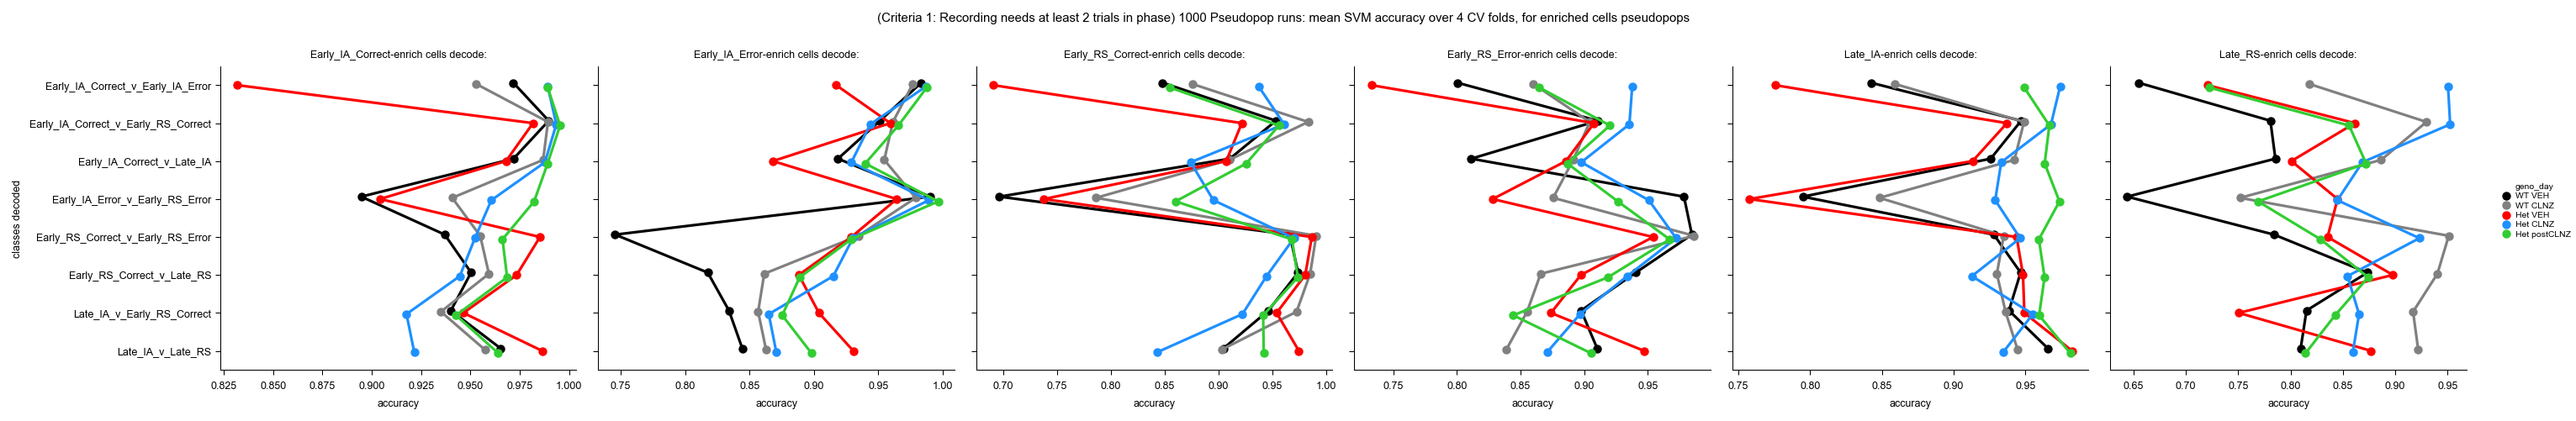

In [27]:
g = sns.catplot(kind = 'point', height = 3.3, data = pop_mean_decoding, dodge = True,sharey = True, sharex = False,col = 'enriched_group', y = 'classes decoded', x = 'accuracy', **geno_color_dict_w_WT_CLNZ)
g.fig.subplots_adjust(top = 0.85)
g.set_titles("{col_name}-enrich cells decode:")
g.fig.suptitle(f" (Criteria 1: Recording needs at least 2 trials in phase) {n_pseudopop_runs} Pseudopop runs: mean SVM accuracy over {k_folds} CV folds, for enriched {units} pseudopops")

## out of distribution generalizations

In [28]:
#create out of distribution handles
# phase_names = stage_names
out_of_dist_train_sets = [
    [phase_names[0], phase_names[3]],#train on- early IA corr vs. early RS corr
     [phase_names[1], phase_names[4]],#train on- early IA err vs.l early RS err
    [phase_names[0], phase_names[1]],#train on-early IA corr vs. early IA err
    [phase_names[3], phase_names[4]],#train on- early RS corr vs. early RS err
    ]
out_of_dist_test_sets = [
    [phase_names[1], phase_names[4]],#test on- early IA err vs.l early RS err
    [phase_names[0], phase_names[3]],#test on- early IA corr vs. early RS corr
    [phase_names[3], phase_names[4]],##test on- early RS corr vs. early RS err
    [phase_names[0], phase_names[1]],##test on- early IA corr vs. early IA err
    ]
print(f"train sets: {out_of_dist_train_sets}")
print(f"Test sets: {out_of_dist_test_sets}")

train sets: [['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error'], ['Early_RS_Correct', 'Early_RS_Error']]
Test sets: [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_RS_Correct', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error']]


#### Run parallel decoding to out of distribution

In [29]:
import itertools
# function for out of distribution decoding
def run_N_decoder_out_of_distribution(class_matrix_store,out_of_dist_train_sets, out_of_dist_test_sets, num_resample:int, test_size= None, k_folds=None, n_pseudopop_run_range= None):
    '''To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  '''
    all_run_record_store = []#create storage for all run information for later concat
    weight_records = []  # Storage for SVM weights and cell IDs
    #declare variables for local use
    reg_penalty = 'l2'
    #local var def
    if test_size is None:
        test_size = 0.5
    if k_folds is None:
        k_folds = 2
    phase_keys = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_keys:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_keys:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix

                for phase_count, phase_pair in enumerate(out_of_dist_train_sets): #once genotype & enrichment filter, specified, compare phase detection
                    class_0_train,class_1_train = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0_train =ensemble_resample_in_phase_dict[class_0_train]
                    class_mat_1_train =ensemble_resample_in_phase_dict[class_1_train]
                    concat_matrix_train,concat_labels_train, =fast_pack_data_local(class_mat_0_train, class_mat_1_train,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    ##iterate over test pairs
                    test_pair = out_of_dist_test_sets[phase_count]
                    # for phase_count, test_pair in enumerate(out_of_dist_test_sets): #once genotype & enrichment filter, specified, compare phase detection
                    class_0_test,class_1_test = test_pair[0], test_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    class_mat_0_test =ensemble_resample_in_phase_dict[class_0_test]
                    class_mat_1_test =ensemble_resample_in_phase_dict[class_1_test]
                    concat_matrix_test,concat_labels_test, =fast_pack_data_local(class_mat_0_test, class_mat_1_test,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    #get test objects for current setup, aligning size of datasets
                    unit_IDs_test =concat_matrix_test.index.values
                    unit_IDs_train = concat_matrix_train.index.values

                    train_IDs_in_test_bool = [u in unit_IDs_test for u in unit_IDs_train] #list of: unit in TEST_UNITS for unit in TRAIN_UNIT
                    test_IDs_in_train_bool = [u in unit_IDs_train for u in unit_IDs_test]#list of: unit in Trin_UNITS for unit in Test_UNIT
                    #now that IDs are extracted, pivot mats
                    concat_matrix_test = concat_matrix_test.T.values
                    concat_matrix_train = concat_matrix_train.T.values
                    #restrict testing to units that have >0 activity in test and trian datasets
                    concat_matrix_test= concat_matrix_test[:,test_IDs_in_train_bool]
                    concat_matrix_train= concat_matrix_train[:,train_IDs_in_test_bool]
                    cv = model_selection.StratifiedShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices

                    ##MODEL
                    split_records = []

                    for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels_train)), concat_labels_train)):
                        #Train on entire generated train mat, test on the same
                        target_info = {"pseudopop_run_num": n_run,
                                       "enriched_group": e_phase,'geno_day': geno_day_curr,
                                       'class_0_train' : class_0_train, 'class_1_train': class_1_train,
                                       'class_0_test' : class_0_test, 'class_1_test': class_1_test,'regularization': reg_penalty, 'date_run': datetime.now()} #speficy info about what classes being decoded

                        model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                        trained_model = model.fit(concat_matrix_train[train,:], concat_labels_train[train])                     # reorg_train_range, reorg_test_range = perm_range(len(concat_labels['train'])),  perm_range(len(concat_labels['test']))                     #reorder activity and labels to remove temporal ordering

                        ## perdiction on test data
                        test_data = concat_matrix_test#concat_matrix_test[test,:]
                        test_labels = concat_labels_test#concat_labels_test[test]
                        prediction_vec =trained_model.predict(test_data)
                        score_real = np.mean(prediction_vec == test_labels)                      # precision, recall,score_real = get_test_precision_recall_acc( concat_matrix_test[test,:], concat_labels_test[test], trained_model)

                        true_pos= np.mean([np.array([prediction_vec == 1]) &  np.array([  test_labels==1])])
                        true_neg= np.mean([np.array([prediction_vec == 0]) &  np.array([  test_labels==0])])
                        false_pos =  np.mean([np.array([prediction_vec == 1]) &  np.array([ test_labels==0])])
                        false_neg =  np.mean([np.array([prediction_vec == 0]) &  np.array([ test_labels==1])])
                        #NEW- 1.15.26- store cosine info
                        # Compute mean vectors for all 4 class/set combinations
                        mean_vectors = {
                            'c0_train': concat_matrix_train[concat_labels_train == 0].mean(axis=0),
                            'c1_train': concat_matrix_train[concat_labels_train == 1].mean(axis=0),
                            'c0_test': concat_matrix_test[concat_labels_test == 0].mean(axis=0),
                            'c1_test': concat_matrix_test[concat_labels_test == 1].mean(axis=0),
                        }
                        ## weight saving key
                        filtered_cell_ids = unit_IDs_train[train_IDs_in_test_bool]
                        decoder_key = f"{n_run}_{e_phase}_{geno_day_curr}_{class_0_train}_{class_1_train}_to_{class_0_test}_{class_1_test}_{split_count}"
                        weight_records.append({'decoder_key': decoder_key,
                                               'weights': trained_model.coef_.flatten().astype(np.float32),
                                               'cell_ids': filtered_cell_ids,
                                               'intercept': trained_model.intercept_[0],
                                               **mean_vectors
                                               })     
                        # Compute all pairwise cosine similarities
                        cosine_sims = {}
                        for (k1, v1), (k2, v2) in itertools.combinations(mean_vectors.items(), 2):
                            cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                            cosine_sims[f'cosine_{k1}_v_{k2}'] = cos_sim

                        curr_split_info = { 'accuracy': score_real,
                                           'num_features_used': trained_model.n_features_in_,
                                           'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0),
                                           'true_pos': true_pos,'true_neg':true_neg,
                                           'false_pos':false_pos, 'false_neg' :false_neg, 
                                           'decoder_key': decoder_key, **cosine_sims
                                            }
                        #for a given split, store in list  ONLY NUMERIC VALS
                        split_records.append(curr_split_info)# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated

                    #end of split loop, avg split performance and move on
                    split_summary = pd.DataFrame.from_records(split_records)
                    split_metrics = split_summary.mean(numeric_only = True)
                    #get metadata,l turn dict to string
                    split_labels = pd.Series(target_info)
                    split_summary = pd.concat([split_metrics,split_labels],ignore_index = False)
                    split_summary['train_size'] = 1-test_size
                    split_summary['k_folds'] = k_folds
                    all_run_record_store.append(split_summary) #store performance information by split run
                #end of phase pair loop
    all_run_record_store =pd.DataFrame.from_records(all_run_record_store)
    weight_save_df = pd.DataFrame.from_records(weight_records)
    return all_run_record_store, weight_save_df

In [30]:
#create partial function and store real data 
# set up parallel batch- 10k shuff is 85 min
decode_type = "out_of_distribution"
num_resample = 800

n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0,n_pseudopop_runs, n_jobs)
partial_param_svm_func = partial(run_N_decoder_out_of_distribution, class_matrix_store,out_of_dist_train_sets,  out_of_dist_test_sets, num_resample, 0.25, 4)
# output_SVM_runs, weight_records = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
# Collect all parallel results first
parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)

# Separate decode scores and weights
output_SVM_runs = [r[0] for r in parallel_results]


N_batches: 10
Batch_size: 100


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  6.7min remaining: 15.5min
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed:  6.7min remaining:  6.7min
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed:  6.8min remaining:  2.9min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:  6.8min finished


#### save out of distribution decoding

In [31]:
parallel_results[0]

(       accuracy  num_features_used  num_nonzero_coef  true_pos  true_neg  \
 0      0.672969               94.0              86.0  0.409062  0.263906   
 1      0.678906               94.0              78.0  0.429688  0.249219   
 2      0.564688               94.0              91.0  0.278438  0.286250   
 3      0.530938               94.0              67.0  0.322500  0.208438   
 4      0.649219               33.0              31.0  0.285781  0.363437   
 ...         ...                ...               ...       ...       ...   
 11995  0.475625               30.0              20.0  0.374219  0.101406   
 11996  0.568750               11.0               5.0  0.389375  0.179375   
 11997  0.556250               11.0               4.0  0.475000  0.081250   
 11998  0.510000               11.0               5.0  0.035000  0.475000   
 11999  0.498125               11.0               5.0  0.058750  0.439375   
 
        false_pos  false_neg  cosine_c0_train_v_c1_train  \
 0       0.236

In [32]:
## PACKAGE information into function ## versioning info
decode_scores = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
decode_scores['train_on'] = decode_scores.class_0_train.str.cat(decode_scores.class_1_train, sep = '_')
decode_scores['test_on'] = decode_scores.class_0_test.str.cat(decode_scores.class_1_test, sep = '_')

decode_file_name_out_distrib = output_folder / Path(f"Decode (Out of Distrib) {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
decode_scores.to_parquet(decode_file_name_out_distrib, compression='snappy')
print(f"decoding csv name: {decode_file_name_out_distrib}")
# decode_scores.to_csv(decode_file_name_out_distrib)
print(decode_scores.info())
decode_scores

decoding csv name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 24_Jan_2026.parquet
<class 'pandas.core.frame.DataFrame'>
Int64Index: 120000 entries, 0 to 11999
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   accuracy                    120000 non-null  float64       
 1   num_features_used           120000 non-null  float64       
 2   num_nonzero_coef            120000 non-null  float64       
 3   true_pos                    120000 non-null  float64       
 4   true_neg                    120000 non-null  float64       
 5   false_pos                   120000 non-null  float64       
 6   false_neg                   120000 non-null  float64       
 7   cosine_c0_train_v_c1_train  120000 non-null  float64       
 8   cosine

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,cosine_c0_train_v_c1_test,...,class_1_test,regularization,date_run,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on
0,0.672969,94.0,86.0,0.409062,0.263906,0.236094,0.090937,0.545579,0.536291,0.566778,...,Early_RS_Error,l2,2026-01-24 11:50:11.107134,0.75,4,0.25,2026-01-24 11:57:01.206853,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
1,0.678906,94.0,78.0,0.429688,0.249219,0.250781,0.070312,0.545289,0.536291,0.391323,...,Early_RS_Correct,l2,2026-01-24 11:50:11.130618,0.75,4,0.25,2026-01-24 11:57:01.206853,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct
2,0.564688,94.0,91.0,0.278438,0.286250,0.213750,0.221562,0.536291,0.545579,0.566778,...,Early_RS_Error,l2,2026-01-24 11:50:11.157734,0.75,4,0.25,2026-01-24 11:57:01.206853,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error
3,0.530938,94.0,67.0,0.322500,0.208438,0.291562,0.177500,0.691418,0.545579,0.391323,...,Early_IA_Error,l2,2026-01-24 11:50:11.185852,0.75,4,0.25,2026-01-24 11:57:01.206853,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error
4,0.649219,33.0,31.0,0.285781,0.363437,0.136562,0.214219,0.502229,0.491005,0.629859,...,Early_RS_Error,l2,2026-01-24 11:50:11.207793,0.75,4,0.25,2026-01-24 11:57:01.206853,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.477500,30.0,20.0,0.376406,0.101094,0.398906,0.123594,0.200546,0.350717,0.543828,...,Early_IA_Error,l2,2026-01-24 11:56:56.277094,0.75,4,0.25,2026-01-24 11:57:01.206853,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error
11996,0.559688,11.0,5.0,0.372500,0.187188,0.312812,0.127500,0.855587,0.855720,0.498487,...,Early_RS_Error,l2,2026-01-24 11:56:56.300854,0.75,4,0.25,2026-01-24 11:57:01.206853,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
11997,0.554375,11.0,4.0,0.470625,0.083750,0.416250,0.029375,0.256509,0.855720,0.815345,...,Early_RS_Correct,l2,2026-01-24 11:56:56.322629,0.75,4,0.25,2026-01-24 11:57:01.206853,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct
11998,0.510625,11.0,5.0,0.038750,0.471875,0.028125,0.461250,0.855720,0.855587,0.498487,...,Early_RS_Error,l2,2026-01-24 11:56:56.335400,0.75,4,0.25,2026-01-24 11:57:01.206853,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error


In [33]:

weight_records

[                                             decoder_key  \
 0      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 1      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 2      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 3      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 4      0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...   
 ...                                                  ...   
 95995       99_Late_RS_WT VEH_Early_RS_Correct_Late_RS_3   
 95996       99_Late_RS_WT VEH_Late_IA_Early_RS_Correct_0   
 95997       99_Late_RS_WT VEH_Late_IA_Early_RS_Correct_1   
 95998       99_Late_RS_WT VEH_Late_IA_Early_RS_Correct_2   
 95999       99_Late_RS_WT VEH_Late_IA_Early_RS_Correct_3   
 
                                                  weights  \
 0      [-1.0240909, 0.13702103, -0.27655149, -0.24926...   
 1      [-0.80594563, -0.026002869, -0.15736365, -0.15...   
 2      [-1.1908058, 0.13224043, -0.21418399, -0.05802...   
 3      [-1.1362371, 0

In [34]:
# Save weights
weight_records = [r[1] for r in parallel_results]  # Flatten the nested lists# 20j, 50batch of 1000- 11 min-5 9pm
weights_df = pd.concat(weight_records)
weights_out_distrib_filename = output_folder / Path(f"out_distrib_SVM_weights_enrich_unit_{n_pseudopop_runs}_pseudopop_{data_type}_{date_tag}.parquet")
weights_df.to_parquet(weights_out_distrib_filename, compression='snappy')
print(f"Weight records saved to: {weights_out_distrib_filename}")
weights_df.head()

Weight records saved to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\out_distrib_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_24_Jan_2026.parquet


,decoder_key,weights,cell_ids,intercept,c0_train,c1_train,c0_test,c1_test
0,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.10850709, -0.62886, -0.86117333, -0.475301...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",1.216914,"[0.26825000000000004, 0.11249999999999995, 0.1...","[0.0675, 0.0, 0.0, 0.012249999999999999, 0.364...","[0.0, 0.11974999999999998, 0.07175000000000006...","[0.12374999999999993, 0.021000000000000005, 0...."
1,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.14967346, -0.5211788, -0.77641463, -0.5604...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",1.193083,"[0.26825000000000004, 0.11249999999999995, 0.1...","[0.0675, 0.0, 0.0, 0.012249999999999999, 0.364...","[0.0, 0.11974999999999998, 0.07175000000000006...","[0.12374999999999993, 0.021000000000000005, 0...."
2,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.26154578, -0.57477385, -0.7812627, -0.6286...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",1.219030,"[0.26825000000000004, 0.11249999999999995, 0.1...","[0.0675, 0.0, 0.0, 0.012249999999999999, 0.364...","[0.0, 0.11974999999999998, 0.07175000000000006...","[0.12374999999999993, 0.021000000000000005, 0...."
3,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.113179676, -0.5154337, -0.83633655, -0.502...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",1.254081,"[0.26825000000000004, 0.11249999999999995, 0.1...","[0.0675, 0.0, 0.0, 0.012249999999999999, 0.364...","[0.0, 0.11974999999999998, 0.07175000000000006...","[0.12374999999999993, 0.021000000000000005, 0...."
4,0_Early_IA_Correct_Het CLNZ_Early_IA_Error_Ear...,"[0.70530736, -0.9208501, -1.3916138, -1.184706...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",0.339342,"[0.0, 0.11974999999999998, 0.07175000000000006...","[0.12374999999999993, 0.021000000000000005, 0....","[0.26825000000000004, 0.11249999999999995, 0.1...","[0.0675, 0.0, 0.0, 0.012249999999999999, 0.364..."


In [35]:
## save metatdata of current run
f = open("last_generalize_decoding_run_info.txt", "w")
decode_run_info_str = f"latest generalize decoding output filename: {decode_file_name_out_distrib}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

latest generalize decoding output filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 24_Jan_2026.parquet. Run end: 24_Jan_2026. Data used: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet


In [36]:
weights_out_distrib_filename

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/figure_5_prep_mid_decoding figures_24_Jan_2026/out_distrib_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_24_Jan_2026.parquet')

## Time-dependent decoding:

#### setup time-dep decoding

In [37]:
def get_start_ends_of_sliced_range(length, chunk_size):
    """ 
    Divides a range of indices into N chunks, ensuring all chunks except the last are the same size.
    Args:
        length (int): The total length of the range.
        chunk_size (int): The size of chunks.
       Returns: np.ndarray: An array of (start, stop) tuples representing the chunk ranges.
    """
    # Compute the size of each chunk
    n_chunks = length // chunk_size
    # Create an array of start indices
    starts = np.arange(0, length, chunk_size)
    # Compute inclusive stop indices so each chunk has exactly chunk_size rows
    stops = starts + chunk_size - 1
    stops[-1] = length - 1
    return np.column_stack((starts, stops))


In [38]:
#function for bootstrapping PCA
def run_SVM_on_timebins_N_bootstrap(class_matrix_store,class_comparisons, frame_cols, num_resample:int,frame_batch_size, bootstrap_range):
    '''TO- run bootstrap to get cosine sim and sil score of decoded classes for each elem N in bootstrap_range '''
    output_list = [] #create class matrix store- DONE PREV
    weight_records = []  # Storage for SVM weights and cell IDs
    #declare variables for local use
    stage_names = class_matrix_store.keys()
    geno_order = class_matrix_store['Late_IA']['Late_IA'].keys()
    #determine range slice creation
    if frame_batch_size is None: #if default argument, batch size == whole frame cols
        col_ranges = [(0, len(frame_cols))] 
    else:  
        col_ranges = get_start_ends_of_sliced_range(len(frame_cols), frame_batch_size)
        col_ranges= [tuple(row) for row in col_ranges]
    #run main body
    for b in bootstrap_range: #create B class matrix store (where b = number of resamples)
        for stage_enriched_in in stage_names:
            for geno_curr in geno_order:
                ensemble_resample_in_phase_dict = {}
                #if doing time-bin wise resampling, create range of mats to useabs             
                for class_name in stage_names: #store the versions for this bootstrap run
                    ensemble_resample_in_phase_dict[class_name]= dict() #allow for ranges for subsample to be used as keys 
                    for subset in col_ranges: #for each start/end value in ranges, draw a matrix within those frame cols of interest
                        subsample_range = frame_cols[subset[0]:subset[1]]
                        class_matrix = resample_into_class_matrix(class_matrix_store,num_resample,stage_enriched_in, class_name, geno_curr, 
                                                                  subsample_range=subsample_range)
                        ensemble_resample_in_phase_dict[class_name][subset] = class_matrix
    
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    subset_info = []
                    
                    for subset in col_ranges: #for each start/end value in ranges, draw a matrix within those frame cols of interest
                        class_mat_0 =ensemble_resample_in_phase_dict[class_0][subset]
                        class_mat_1 =ensemble_resample_in_phase_dict[class_1][subset]
                        concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels
                        cell_ids = concat_matrix.index.values  # Capture cell IDs BEFORE .values.T

                        concat_matrix = concat_matrix.values.T #.T.values of concat matrix is to reshape mat into what scikit wants from you
                        cv = model_selection.ShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices
                        
                        target_info = { 'pseudopop_run_num': b, 'enriched_group': stage_enriched_in,'class_0': class_0, 'class_1': class_1, 'geno_day': geno_curr, 
                                     'frame_subset': subset, 'bin_start_index': subset[0], 'bin_end_index': subset[1], 'bin_start_str': frame_cols[subset[0]], 
                                     } 

                        split_summary = []
                        for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels)), concat_labels)):
                            model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                            trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                            precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                             #get correct bin names
                            if subset[1]==len(frame_cols):
                                bin_end_str = frame_cols[subset[1]-1]
                            else:
                                bin_end_str = frame_cols[subset[1]]   
                            #ending str = moved 1 index if index == length of acutal frame col, as you're indexing in exclusive manner
                            curr_split_info = {**target_info, 'mean_acc': score_real,'num_features_used': trained_model.n_features_in_,
                                               'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), }
                            decoder_key = f"{b}_{stage_enriched_in}_{geno_curr}_{class_0}_{class_1}_{subset}_{split_count}"
                            weight_records.append({'decoder_key': decoder_key,
                                                   'weights': trained_model.coef_.flatten().astype(np.float32),
                                                   'cell_ids': cell_ids,
                                                   'intercept': trained_model.intercept_[0]})
                            
                           #     'train_pos_sample':  np.sum(concat_labels[train] ==1), 'train_neg_sample':np.sum(concat_labels[train] ==0), 
                           #                     'test_pos_sample':np.sum(concat_labels[train]==1), 'test_neg_sample': np.sum(concat_labels[train]==1),
                           # 'class_0_IDs': class_mat_0.index.values,
                           #                     'class_1_IDs':class_mat_1.index.values, 'date_run': datetime.today().strftime('%Y-%m-%d'),}
                            # curr_split_info = {**target_info,'split': split_count, 'mean_acc': score_real,}  
                            # split_summary =curr_split_info #gather performance for split N
                            split_summary.append(curr_split_info['mean_acc'])# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                        #save split info for the given subset
                        #after finishing split run, average then store
                        average_acc = np.mean(split_summary)
                        split_summary = {**target_info,'mean_acc': average_acc,'bin_end_str': bin_end_str, 'bin_default_size':frame_batch_size} 
                        output_list.append(split_summary) #append dict
                    # all_run_record_store.append(pd.DataFrame.from_records(split_summary)) #store performance information by split run
    #once done with all bootstraps, create from records
    output_list =pd.DataFrame.from_records(output_list)
    weight_save_df = pd.DataFrame.from_records(weight_records)
    return output_list, weight_save_df

In [39]:

frame_batch_size= 8
x = run_SVM_on_timebins_N_bootstrap(class_matrix_store,class_comparisons, numeric_col, 400,12, [1])
x

(      pseudopop_run_num    enriched_group           class_0           class_1  \
 0                     1  Early_IA_Correct  Early_IA_Correct    Early_IA_Error   
 1                     1  Early_IA_Correct  Early_IA_Correct    Early_IA_Error   
 2                     1  Early_IA_Correct  Early_IA_Correct    Early_IA_Error   
 3                     1  Early_IA_Correct  Early_IA_Correct    Early_IA_Error   
 4                     1  Early_IA_Correct  Early_IA_Correct    Early_IA_Error   
 ...                 ...               ...               ...               ...   
 1435                  1           Late_RS           Late_IA  Early_RS_Correct   
 1436                  1           Late_RS           Late_IA  Early_RS_Correct   
 1437                  1           Late_RS           Late_IA  Early_RS_Correct   
 1438                  1           Late_RS           Late_IA  Early_RS_Correct   
 1439                  1           Late_RS           Late_IA  Early_RS_Correct   
 
       geno_da

In [40]:
# set up parallel batch
num_resample = 400
n_jobs = 10
frame_batch_size= 12
n_bootstraps  = 1000
start_end_iter = make_chunked_iterator_of_ranges(0,n_bootstraps, n_jobs)
#12 min, 100 runs 
#36min- 1k runs 
partial_timebin_svm_func = partial(run_SVM_on_timebins_N_bootstrap, class_matrix_store,class_comparisons,
                                   numeric_col, num_resample, frame_batch_size)
# Collect all parallel results first
parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_timebin_svm_func)(x) for x in start_end_iter)
# Separate decode scores and weights
output_SVM_runs = [r[0] for r in parallel_results]


N_batches: 10
Batch_size: 100


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed: 34.3min remaining: 80.0min
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed: 34.4min remaining: 34.4min
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed: 34.5min remaining: 14.8min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed: 34.6min finished


In [41]:
## PACKAGE information into function ## versioning info
timedecode_scores= package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
timedecode_scores['classes decoded'] = timedecode_scores.class_0.str.cat(timedecode_scores.class_1, sep = '_v_')#.astype('category')
timedecode_scores.head()

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 11)",0,11,-3.0s to -2.75s,1.00000,-0.25s to -0.0s,12,0.25,2026-01-24 12:32:08.294843,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(12, 23)",12,23,0.0s to 0.25s,0.99500,2.75s to 3.0s,12,0.25,2026-01-24 12:32:08.294843,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 35)",24,35,3.0s to 3.25s,0.99250,5.75s to 6.0s,12,0.25,2026-01-24 12:32:08.294843,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(36, 47)",36,47,6.0s to 6.25s,0.99875,8.75s to 9.0s,12,0.25,2026-01-24 12:32:08.294843,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 59)",48,59,9.0s to 9.25s,0.99875,11.75s to 12.0s,12,0.25,2026-01-24 12:32:08.294843,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error


In [42]:

timedecode_scores = timedecode_scores.rename({'class_0': 'Phase1', 'class_1':'Phase2'}, axis = 1)
timedecode_scores['timebin_size'] = hyper_param_dict['bin_size']
timedecode_scores['run_end_time'] = datetime.now()
timedecode_scores['dataset_folder_name'] = str(trial_df_filename)
timedecode_scores.bin_start_str = timedecode_scores.bin_start_str.str.split(' to ').str[0]
timedecode_scores.bin_end_str = timedecode_scores.bin_end_str.str.split(' to ').str[1]
timedecode_scores['bin_name'] = timedecode_scores.bin_start_str.str.cat( timedecode_scores.bin_end_str, sep = ' to ')
timedecode_scores['frame_subset'] = timedecode_scores['frame_subset']#.astype('category')
timedecode_scores.loc[:,['enriched_group', 'Phase1','Phase2', 'geno_day']] = timedecode_scores.loc[:,['enriched_group', 'Phase1','Phase2', 'geno_day']]#.astype('category')
timedecode_scores.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1440000 entries, 0 to 143999
Data columns (total 17 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   pseudopop_run_num    1440000 non-null  int32         
 1   enriched_group       1440000 non-null  object        
 2   Phase1               1440000 non-null  object        
 3   Phase2               1440000 non-null  object        
 4   geno_day             1440000 non-null  object        
 5   frame_subset         1440000 non-null  object        
 6   bin_start_index      1440000 non-null  int32         
 7   bin_end_index        1440000 non-null  int32         
 8   bin_start_str        1440000 non-null  object        
 9   mean_acc             1440000 non-null  float64       
 10  bin_end_str          1440000 non-null  object        
 11  bin_default_size     1440000 non-null  int64         
 12  timebin_size         1440000 non-null  float64       
 13

#### save time-dependent decoding

In [43]:
timedecode_file_name = output_folder / Path( f"Timebin {frame_batch_size}_window Decoding- {n_bootstraps}_bootstrap {data_type} {date_tag}.parquet")
timedecode_scores.to_parquet(timedecode_file_name, compression='snappy')
print(f"decoding file name: {timedecode_file_name}")
# timedecode_scores.to_csv(decode_csv_name)
print(timedecode_scores.info())
timedecode_scores

decoding file name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\Timebin 12_window Decoding- 1000_bootstrap post_outcome_activity 24_Jan_2026.parquet
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1440000 entries, 0 to 143999
Data columns (total 17 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   pseudopop_run_num    1440000 non-null  int32         
 1   enriched_group       1440000 non-null  object        
 2   Phase1               1440000 non-null  object        
 3   Phase2               1440000 non-null  object        
 4   geno_day             1440000 non-null  object        
 5   frame_subset         1440000 non-null  object        
 6   bin_start_index      1440000 non-null  int32         
 7   bin_end_index        1440000 non-null  int32         
 8   bin_start_str        1440000 non-null  object        
 9   

,pseudopop_run_num,enriched_group,Phase1,Phase2,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 11)",0,11,-3.0s,1.00000,-0.0s,12,0.25,2026-01-24 12:32:09.018556,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,-3.0s to -0.0s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(12, 23)",12,23,0.0s,0.99500,3.0s,12,0.25,2026-01-24 12:32:09.018556,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,0.0s to 3.0s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 35)",24,35,3.0s,0.99250,6.0s,12,0.25,2026-01-24 12:32:09.018556,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,3.0s to 6.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(36, 47)",36,47,6.0s,0.99875,9.0s,12,0.25,2026-01-24 12:32:09.018556,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,6.0s to 9.0s
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 59)",48,59,9.0s,0.99875,12.0s,12,0.25,2026-01-24 12:32:09.018556,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,9.0s to 12.0s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143995,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(12, 23)",12,23,0.0s,0.82500,3.0s,12,0.25,2026-01-24 12:32:09.018556,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,0.0s to 3.0s
143996,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(24, 35)",24,35,3.0s,0.91750,6.0s,12,0.25,2026-01-24 12:32:09.018556,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,3.0s to 6.0s
143997,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(36, 47)",36,47,6.0s,0.90000,9.0s,12,0.25,2026-01-24 12:32:09.018556,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,6.0s to 9.0s
143998,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(48, 59)",48,59,9.0s,0.86625,12.0s,12,0.25,2026-01-24 12:32:09.018556,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,9.0s to 12.0s


In [44]:
## save metatdata of current run
f = open("last_time_decoding_run_info.txt", "w")
decode_run_info_str = f"latest time-based decoding output filename: {timedecode_file_name}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

latest time-based decoding output filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\Timebin 12_window Decoding- 1000_bootstrap post_outcome_activity 24_Jan_2026.parquet. Run end: 24_Jan_2026. Data used: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet


In [45]:
# Save weights
weight_records = [r[1] for r in parallel_results]  # Flatten the nested lists# 20j, 50batch of 1000- 11 min-5 9pm
weights_df = pd.concat(weight_records)
weights_timedep_filename = output_folder / Path(f"timedep_SVM_weights_enrich_unit_{n_pseudopop_runs}_pseudopop_{data_type}_{date_tag}.parquet")
weights_df.to_parquet(weights_timedep_filename, compression='snappy')
print(f"Weight records saved to: {weights_timedep_filename}")
weights_df.head()

Weight records saved to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026\timedep_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_24_Jan_2026.parquet


,decoder_key,weights,cell_ids,intercept
0,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.92907953, -0.13762856, 0.036545318, -0.231...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",0.836638
1,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.8897455, -0.11063293, -0.0032293675, -0.30...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",0.840369
2,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-1.0099202, -0.04693515, -0.00990514, -0.1582...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",0.803894
3,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.86123544, -0.07236101, -0.040143814, -0.30...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",0.834687
4,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.17594635, 0.31042632, -0.008022607, -0.210...","[13_3_HET_RS2-113, 13_3_HET_RS2-115, 13_3_HET_...",0.733672


In [46]:
weights_timedep_filename

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/figure_5_prep_mid_decoding figures_24_Jan_2026/timedep_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_24_Jan_2026.parquet')

## save summaries of decoding performance

In [47]:
# Define mapping of decoding types to their output file variables
# Each entry: (decoding_type_name, output_file_variable_name)
decoding_types_config = [
    ('in_distribution', 'decode_file_name'),
    ('out_of_distribution', 'decode_file_name_out_distrib'),
    ('out_of_distribution_single_stage', 'decode_file_generalize_single_stage'),
    ('timebin_decoding', 'timedecode_file_name'),
]
weight_filenames ={'timebin_decoding': weights_timedep_filename,
                    'in_distribution': weights_in_distrib_filename,
                    'out_of_distribution': weights_out_distrib_filename}
# Create run info dataframes for all performed decoding types
run_info_dfs = []
for decoding_type, file_var_name in decoding_types_config:
    # Check if the output file variable exists (i.e., that decoding was performed)
    if file_var_name in dir():
        output_file = eval(file_var_name)
        run_info = {
            'run_date': date_tag, 
            'decoding_type': decoding_type, 
            'run_end_time': datetime.now(),
            'run_dataset_used': str(trial_df_filename),
            'run_output_filename': output_file, 
            'n_jobs': n_jobs,
            'n_iterations': n_pseudopop_runs if 'timebin' not in decoding_type else n_bootstraps, 
            'activity_file': cell_activity_file_name if 'out_of_distribution' == decoding_type else 'N/A',
            'weight_file_saved': weight_filenames.get(decoding_type, 'N/A')
        }
        run_info_dfs.append(pd.DataFrame([run_info]))
        print(f"Created run info for: {decoding_type}")
    else:
        print(f"Skipped {decoding_type} - {file_var_name} not found (decoding not performed)")

# Concatenate all run info dataframes
current_runs_info = pd.concat(run_info_dfs, ignore_index=True)
current_runs_info

Created run info for: in_distribution
Created run info for: out_of_distribution
Skipped out_of_distribution_single_stage - decode_file_generalize_single_stage not found (decoding not performed)
Created run info for: timebin_decoding


,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved
0,24_Jan_2026,in_distribution,2026-01-24 12:34:01.751565,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,N/A,C:\Users\13car\Dropbox\local_github_repos_pers...
1,24_Jan_2026,out_of_distribution,2026-01-24 12:34:01.763149,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...
2,24_Jan_2026,timebin_decoding,2026-01-24 12:34:01.765151,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,N/A,C:\Users\13car\Dropbox\local_github_repos_pers...


In [48]:

generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
svm_file_loc = data_dir
if not os.path.exists(generalize_svm_record_file):    #create locally then save
    run_record_generalize = current_runs_info
else: #load and add to it 
    run_record_generalize= pd.read_csv(generalize_svm_record_file)
    run_record_generalize = pd.concat([run_record_generalize, current_runs_info])
    run_record_generalize = run_record_generalize.drop([c for c in run_record_generalize.columns if 'Unnamed' in c],axis = 1)
#if CSV doesn't exist, create
run_record_generalize.to_csv(generalize_svm_record_file)
run_record_generalize

,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved
0,24_Jan_2026,in_distribution,2026-01-24 12:34:01.751565,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,N/A,C:\Users\13car\Dropbox\local_github_repos_pers...
1,24_Jan_2026,out_of_distribution,2026-01-24 12:34:01.763149,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...
2,24_Jan_2026,timebin_decoding,2026-01-24 12:34:01.765151,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,N/A,C:\Users\13car\Dropbox\local_github_repos_pers...


In [49]:
print(os.getcwd())
print(f"used {run_record_generalize.run_dataset_used.unique()} dataset for current runs")

C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_24_Jan_2026
used ['c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet'] dataset for current runs


In [50]:
#all decoding names: 
# decoding file name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Timebin Decoding- 10000_bootstrap post_outcome_activity 16_Jan_2026.parquet
